In [1]:
%load_ext autoreload
%autoreload 2

In [7]:
!!pip install -q omegaconf

["\x1b  DEPRECATION: Building 'antlr4-python3-runtime' using the legacy setup.py bdist_wheel mechanism, which will be removed in a future version. pip 25.3 will enforce this behaviour change. A possible replacement is to use the standardized build interface by setting the `--use-pep517` option, (possibly combined with `--no-build-isolation`), or adding a `pyproject.toml` file to the source tree of 'antlr4-python3-runtime'. Discussion can be found at https://github.com/pypa/pip/issues/6334\x1b\x1b",
 '\x1b']

# Load and Reconstruct SFT Tokenized Data

This notebook demonstrates how to:
1. Load tokenized data from Megatron indexed dataset (.idx and .bin files)
2. Separate image and text tokens
3. Reconstruct images from vision tokens
4. Decode text from text tokens

In [1]:
import sys
import torch
import numpy as np
import struct
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

# Add project paths
project_root = Path('/iopsstor/scratch/cscs/rkreft/benchmark-image-tokenizer')
sys.path.append(str(project_root))
sys.path.append(str(project_root / 'vision_tokenization'))

/users/rkreft/miniconda3/envs/myenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Load Indexed Dataset Using MemMap

In [6]:
class SimpleIndexedDatasetReader:
    """Simple reader for Megatron indexed dataset files using numpy memmap."""
    
    def __init__(self, path_prefix):
        self.path_prefix = path_prefix
        self.idx_path = path_prefix + '.idx'
        self.bin_path = path_prefix + '.bin'
        
        # Read index file
        with open(self.idx_path, 'rb') as f:
            # Read header
            header = f.read(9)  # MMIDIDX\x00\x00
            assert header == b"MMIDIDX\x00\x00", f"Invalid header: {header}"
            
            # Read version
            version = struct.unpack('<Q', f.read(8))[0]
            assert version == 1, f"Unsupported version: {version}"
            
            # Read dtype code
            dtype_code = struct.unpack('<B', f.read(1))[0]
            self.dtype = self._dtype_from_code(dtype_code)
            
            # Read counts
            self.sequence_count = struct.unpack('<Q', f.read(8))[0]
            self.document_count = struct.unpack('<Q', f.read(8))[0]
            
            print(f"Sequence count: {self.sequence_count}")
            print(f"Document count: {self.document_count}")
            print(f"Data type: {self.dtype}")
            
            # Read sequence lengths
            self.sequence_lengths = np.frombuffer(
                f.read(self.sequence_count * 4), dtype=np.int32
            )
            
            # Read sequence pointers (byte offsets)
            self.sequence_pointers = np.frombuffer(
                f.read(self.sequence_count * 8), dtype=np.int64
            )
            
            # Read document indices
            self.document_indices = np.frombuffer(
                f.read(self.document_count * 8), dtype=np.int64
            )
        
        # Memory-map the binary data file
        self.bin_data = np.memmap(self.bin_path, mode='r', order='C', dtype=self.dtype)
        
    def _dtype_from_code(self, code):
        """Convert dtype code to numpy dtype."""
        dtype_map = {
            1: np.uint8,
            2: np.int8,
            3: np.int16,
            4: np.int32,
            5: np.int64,
            6: np.float64,
            7: np.float32,
            8: np.uint16
        }
        return dtype_map.get(code, np.int32)
    
    def __len__(self):
        return self.sequence_count
    
    def get(self, idx):
        """Get tokens for a specific sequence index."""
        if idx < 0 or idx >= self.sequence_count:
            raise IndexError(f"Index {idx} out of range [0, {self.sequence_count})")
        
        # Get byte offset and length
        offset = self.sequence_pointers[idx]
        length = self.sequence_lengths[idx]
        
        # Calculate element offset (offset is in bytes)
        elem_offset = offset // self.dtype().itemsize
        
        # Read tokens from memmap
        tokens = self.bin_data[elem_offset:elem_offset + length]
        
        return tokens

# Sft data path
data_prefix = Path('/users/rkreft/benchmark-image-tokenzier/vision_tokenization/tokenized_outputs/instruct_1000_s2/CLEVR_sft/256x256_2048x2048/rank_0_shard_1_2')
# paired data path
#data_prefix = Path('/users/rkreft/benchmark-image-tokenzier/vision_tokenization/tokenized_outputs/paired_100/128x128_2048x2048/rank_0_shard_0_1')
# Image only path
#data_prefix = Path('/users/rkreft/benchmark-image-tokenzier/vision_tokenization/tokenized_outputs/image_only_1000_s2/128x128_2048x2048/rank_0_shard_1_2')

print(f"Loading data from: {data_prefix}")
print(f"Checking files:")
print(f"  .idx file exists: {(Path(str(data_prefix) + '.idx')).exists()}")
print(f"  .bin file exists: {(Path(str(data_prefix) + '.bin')).exists()}")

# Load the indexed dataset
dataset = SimpleIndexedDatasetReader(str(data_prefix))

print(f"\nTotal samples in dataset: {len(dataset)}")
print(f"Dataset dtype: {dataset.dtype}")

Loading data from: /users/rkreft/benchmark-image-tokenzier/vision_tokenization/tokenized_outputs/instruct_1000_s2/CLEVR_sft/256x256_2048x2048/rank_0_shard_1_2
Checking files:
  .idx file exists: True
  .bin file exists: True
Sequence count: 500
Document count: 501
Data type: <class 'numpy.int32'>

Total samples in dataset: 500
Dataset dtype: <class 'numpy.int32'>


## 2. Initialize Tokenizer and Vision Model

In [19]:
# Initialize text tokenizer
#tokenizer_path = '/capstor/store/cscs/swissai/infra01/MLLM/apertus_emu3.5_instruct_tokenizer'
tokenizer_path = '/capstor/store/cscs/swissai/infra01/MLLM/apertus_emu3.5_tokenizer'
text_tokenizer = AutoTokenizer.from_pretrained(
    tokenizer_path,
    trust_remote_code=True,
    fast=True
)

In [20]:
# Import the correct SFT tokenizer class
from vision_tokenization.vokenizers.emu import EMUSftTokenizer

# Initialize SFT tokenizer for image decoding
device = "cuda" if torch.cuda.is_available() else "cpu"
sft_tokenizer = EMUSftTokenizer(
    text_tokenizer_path=tokenizer_path,
    device=device,
    min_pixels=256*256,  # Minimum pixels for image preprocessing
    max_pixels=2048*2048  # Maximum pixels for image preprocessing
)

print(f"Device: {device}")
print(f"Image end token ID: {sft_tokenizer.img_end_id}")


Loading vision tokenizer: Emu3.5 from /capstor/store/cscs/swissai/infra01/MLLM/Emu3.5-VisionTokenizer
Loading Emu3_5_IBQ from /capstor/store/cscs/swissai/infra01/MLLM/Emu3.5-VisionTokenizer...
✓ Emu3_5_IBQ loaded successfully
Model device: cuda
Codebook size: 131072
Codebook dimension: 256
Emu3_5_IBQ loaded:
  Total parameters: 455.34M (455,336,963)
  Trainable parameters: 455.34M (455,336,963)
Device: cuda
Image end token ID: 131074


In [21]:
# Access BOS token
bos_token = text_tokenizer.bos_token
bos_token_id = text_tokenizer.bos_token_id

# Access EOS token
eos_token = text_tokenizer.eos_token
eos_token_id = text_tokenizer.eos_token_id

# Print them
print(f"BOS token: '{bos_token}' (ID: {bos_token_id})")
print(f"EOS token: '{eos_token}' (ID: {eos_token_id})")

BOS token: '<s>' (ID: 1)
EOS token: '</s>' (ID: 2)


Only run this if you have SFT tokenizer loaded (text tokenizer with chat template)

In [10]:
t = [
    {"role": "system", "content": ""},
    {
      'role': 'user',
      'content': 'Hello, how are you?',
    },
    {
      'role': 'assistant',
      'content': "I'm doing great. How can I help you today?",
    },
  ]
result = text_tokenizer.apply_chat_template(t, tokenize=False, add_generation_prompt=False, add_system_prompt=False)
print(result)


<s><|system_start|><|system_end|><|developer_start|>Deliberation: disabled
Tool Capabilities: disabled<|developer_end|><|user_start|>Hello, how are you?<|user_end|><|assistant_start|>I'm doing great. How can I help you today?<|assistant_end|>


## 3. Load and Analyze Sample

In [34]:
def load_sample(dataset, idx):
    """Load a single sample from the dataset."""
    tokens = dataset.get(idx)
    tokens_tensor = torch.tensor(tokens, dtype=torch.long)
    return tokens_tensor

def split_image_text_tokens(tokens, img_end_id):
    """Split tokens into image and text portions."""
    # Find the position of img_end token
    img_end_mask = (tokens == img_end_id)
    
    if img_end_mask.any():
        img_end_idx = img_end_mask.nonzero(as_tuple=True)[0][0].item()
        image_tokens = tokens[:img_end_idx + 1]  # Include img_end
        text_tokens = tokens[img_end_idx + 1:]
        return image_tokens, text_tokens
    else:
        # No image tokens found, all are text tokens
        return None, tokens

def decode_text(text_tokens, text_tokenizer):
    """Decode text tokens using the tokenizer.
    
    Args:
        text_tokens: Tensor of text token IDs
        sft_tokenizer: EMU3ImageSftDataTokenizer instance (contains text tokenizer)
    
    Returns:
        Decoded text string
    """
    if text_tokens is None or len(text_tokens) == 0:
        return ""
    
    # Convert to list if tensor
    if torch.is_tensor(text_tokens):
        text_tokens = text_tokens.tolist()
    
    # Decode using the text tokenizer inside sft_tokenizer
    decoded_text = text_tokenizer.decode(text_tokens, skip_special_tokens=False)
    return decoded_text

# Load first sample
sample_idx = 0
tokens = load_sample(dataset, sample_idx)
decoded = decode_text(tokens, text_tokenizer)

print(f"\nSample {sample_idx}:")
print(f"Total tokens: {len(tokens)}")
print(f"First 20 tokens: {tokens[:40].tolist()}")
print(f"Last 20 tokens: {tokens[-40:].tolist()}")
print(f"First 20 decoded: {decoded[:40]}")
print(f"Last 20 decoded: {decoded[-40:]}")

print(f"Decoded: {decoded}")

#Split into image and text
print("\n===== Image and Text Token Split =====")
image_tokens, text_tokens = split_image_text_tokens(tokens, sft_tokenizer.img_end_id)

if image_tokens is not None:
    print(f"\nImage tokens: {len(image_tokens)}")
    print(f"Text tokens: {len(text_tokens)}")
    
    # Decode and display text
    if text_tokens is not None and len(text_tokens) > 0:
        decoded_text = decode_text(text_tokens, text_tokenizer)
        print(f"\nDecoded text (first 200 chars):")
        print(decoded_text[:200] + "..." if len(decoded_text) > 200 else decoded_text)
else:
    print("\nNo image tokens found in this sample")


Sample 0:
Total tokens: 291
First 20 tokens: [1, 131073, 1049, 1052, 1042, 1049, 1057, 131075, 188032, 167205, 155663, 211728, 145450, 209572, 241942, 206728, 145113, 136083, 243063, 240481, 157179, 150592, 243932, 246891, 211772, 223117, 159581, 131076, 224312, 258332, 142574, 144845, 225466, 233493, 196280, 192786, 241435, 174794, 192786, 238482]
Last 20 tokens: [243832, 165771, 151028, 134123, 188857, 258972, 135779, 147640, 182976, 224463, 166154, 166676, 233537, 143662, 231909, 174393, 131076, 207162, 218081, 251464, 257078, 155741, 261257, 223734, 182234, 232166, 199504, 240241, 221536, 260000, 171243, 134242, 258920, 134281, 183620, 210434, 131076, 131077, 131074, 2]
First 20 decoded: <s><|img_start|>14*19<|img_token_start|>
Last 20 decoded: row|><|img_end_of_frame|><|img_end|></s>
Decoded: <s><|img_start|>14*19<|img_token_start|><|visual token 056760|><|visual token 035933|><|visual token 024391|><|visual token 080456|><|visual token 014178|><|visual token 078300|><|visual tok

## 4. Decode Text Tokens

In [26]:
def reconstruct_image_from_tokens(image_tokens, sft_tokenizer):
    """Reconstruct image from vision tokens using row-by-row extraction.

    This function properly handles EMU3's special tokens structure:
    - img_start: Beginning of image
    - img_end_of_row: End of line/row (eol_id)
    - img_end_of_frame: End of frame (eof_id)
    - img_end: End of image
    - visual tokens: <|visual token XXXXXX|> format

    Args:
        image_tokens: Tensor of token IDs including special tokens
        sft_tokenizer: EMU3ImageSftDataTokenizer instance (contains text tokenizer)

    Returns:
        PIL Image or None if reconstruction fails
    """
    try:
        # Get special token IDs from sft_tokenizer
        img_end_id = sft_tokenizer.img_end_id
        eol_id = sft_tokenizer.eol_id  # End of line (the token is <|img_end_of_row|>)
        eof_id = sft_tokenizer.eof_id  # End of frame
        img_start_id = sft_tokenizer.img_start_id
        
        # Get the ID of the first visual token to determine the range
        # Visual tokens are in format <|visual token 000000|> through <|visual token XXXXXX|>
        first_visual_token_id = sft_tokenizer.text_tokenizer.convert_tokens_to_ids('<|visual token 000000|>')
        
        # Get the actual codebook size from the vision tokenizer
        codebook_size = sft_tokenizer.image_tokenizer.codebook_size
        
        print(f"Special token IDs: img_start={img_start_id}, eol={eol_id}, eof={eof_id}, img_end={img_end_id}")
        print(f"First visual token ID: {first_visual_token_id}")
        print(f"Codebook size: {codebook_size}")

        # Extract visual tokens row by row, properly handling special tokens
        rows = []
        current_row = []
        in_image = False

        for i, token_id in enumerate(image_tokens.tolist()):
            # Start of image
            if token_id == img_start_id:
                in_image = True
                continue

            # Skip if not in image yet
            if not in_image:
                continue

            # End of line/row - save current row and start new one
            if token_id == eol_id:
                if current_row:  # Only add non-empty rows
                    rows.append(current_row)
                current_row = []
            # End of frame or image - we're done
            elif token_id == eof_id or token_id == img_end_id:
                if current_row:  # Add any remaining tokens
                    rows.append(current_row)
                break
            # Visual token (check if it's >= first_visual_token_id, as visual tokens come after all text tokens)
            elif token_id >= first_visual_token_id:
                # Convert token ID to codebook index
                # Visual tokens are consecutive starting from first_visual_token_id
                codebook_idx = token_id - first_visual_token_id
                
                # Validate the codebook index is within the actual codebook size
                if 0 <= codebook_idx < codebook_size:
                    current_row.append(codebook_idx)
                else:
                    print(f"Warning: Invalid codebook index {codebook_idx} from token {token_id} (codebook size: {codebook_size})")
            # Skip other special tokens or text tokens

        if not rows:
            print("No visual tokens found")
            return None

        # Check row consistency
        row_lengths = [len(row) for row in rows]
        unique_lengths = list(set(row_lengths))

        if len(unique_lengths) != 1:
            print(f"Warning: Inconsistent row lengths: min={min(row_lengths)}, max={max(row_lengths)}")
            print(f"First 10 row lengths: {row_lengths[:10]}")
            # Use the most common width
            from collections import Counter
            width_counts = Counter(row_lengths)
            target_width = width_counts.most_common(1)[0][0]
            print(f"Using most common width: {target_width}")

            # Filter rows to only those with target width
            rows = [row for row in rows if len(row) == target_width]
        else:
            target_width = unique_lengths[0]

        height = len(rows)
        width = target_width

        print(f"Extracted {height}x{width} visual tokens grid")

        # Flatten rows to get all indices
        visual_indices = [idx for row in rows for idx in row]
        total_tokens = len(visual_indices)
        expected_tokens = height * width

        if total_tokens != expected_tokens:
            print(f"Warning: Have {total_tokens} tokens but expected {expected_tokens}")
            return None

        # Create tensor and reshape
        indices_tensor = torch.tensor(visual_indices, dtype=torch.long)
        indices_tensor = indices_tensor.reshape(1, height, width)

        print(f"Indices tensor shape: {indices_tensor.shape}")
        print(f"Indices range: [{indices_tensor.min().item()}, {indices_tensor.max().item()}]")

        # Move to CUDA for decoding
        device = 'cuda' if torch.cuda.is_available() else 'cpu'
        indices_tensor = indices_tensor.to(device)

        # Decode using EMU3 vision tokenizer (sft_tokenizer has it as image_tokenizer)
        if not hasattr(sft_tokenizer, 'image_tokenizer') or sft_tokenizer.image_tokenizer is None:
            print("Error: sft_tokenizer.image_tokenizer is not initialized")
            return None

        # Decode to image
        print("Decoding indices to image...")
        with torch.no_grad():
            reconstructed_tensor = sft_tokenizer.image_tokenizer.decode(indices_tensor)

        # Convert to PIL image
        reconstructed_pil = sft_tokenizer.image_tokenizer.postprocess(reconstructed_tensor)
        print(f"Successfully reconstructed image: {reconstructed_pil.size}")

        return reconstructed_pil

    except Exception as e:
        print(f"Error reconstructing image: {e}")
        import traceback
        traceback.print_exc()
        return None

## 5. Reconstruct Image from Vision Tokens


=== Reconstructing Image ===
Special token IDs: img_start=131073, eol=131076, eof=131077, img_end=131074
First visual token ID: 131272
Codebook size: 131072
Extracted 14x19 visual tokens grid
Indices tensor shape: torch.Size([1, 14, 19])
Indices range: [438, 130433]
Decoding indices to image...
Successfully reconstructed image: (304, 224)


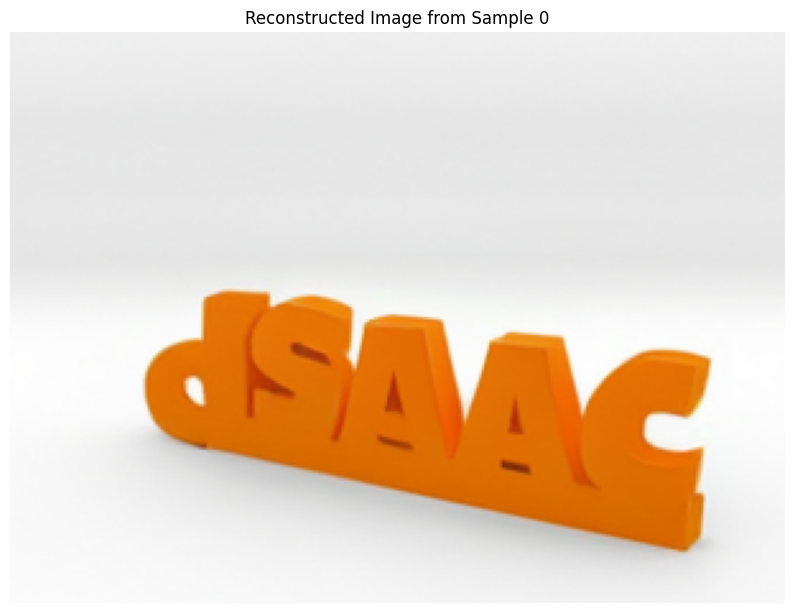

Image size: (304, 224)


In [35]:
# Reconstruct the image
if image_tokens is not None and len(image_tokens) > 0:
    print("\n=== Reconstructing Image ===")
    # Only pass sft_tokenizer since it contains everything we need
    reconstructed_image = reconstruct_image_from_tokens(image_tokens, sft_tokenizer)
    
    if reconstructed_image:
        # Display the reconstructed image
        plt.figure(figsize=(10, 10))
        plt.imshow(reconstructed_image)
        plt.title(f"Reconstructed Image from Sample {sample_idx}")
        plt.axis('off')
        plt.show()
        
        print(f"Image size: {reconstructed_image.size}")
    else:
        print("Failed to reconstruct image")
else:
    print("No image tokens to reconstruct")

## 6. Process Multiple Samples

In [36]:
def process_sample(dataset, idx, sft_tokenizer):
    """Process a single sample and return decoded content.
    
    Args:
        dataset: SimpleIndexedDatasetReader instance
        idx: Sample index to process
        sft_tokenizer: EMU3ImageSftDataTokenizer instance (contains both text and image tokenizers)
    
    Returns:
        Dictionary with processed sample data
    """
    # Load tokens
    tokens = load_sample(dataset, idx)
    
    # Split into image and text
    image_tokens, text_tokens = split_image_text_tokens(tokens, sft_tokenizer.img_end_id)
    
    result = {
        'idx': idx,
        'total_tokens': len(tokens),
        'image_tokens': len(image_tokens) if image_tokens is not None else 0,
        'text_tokens': len(text_tokens) if text_tokens is not None else 0,
    }
    
    # Decode text using text_tokenizer
    if text_tokens is not None and len(text_tokens) > 0:
        result['text'] = decode_text(text_tokens, text_tokenizer)
    else:
        result['text'] = ""
    
    # Reconstruct image using sft_tokenizer
    if image_tokens is not None and len(image_tokens) > 0:
        result['image'] = reconstruct_image_from_tokens(image_tokens, sft_tokenizer)
    else:
        result['image'] = None
    
    return result

# Process first 3 samples
n_samples = min(3, len(dataset))
results = []

for i in range(n_samples):
    print(f"\n{'='*60}")
    print(f"Processing sample {i}...")
    # Only pass sft_tokenizer now
    result = process_sample(dataset, i, sft_tokenizer)
    results.append(result)
    
    print(f"\nSample {i} Statistics:")
    print(f"  Total tokens: {result['total_tokens']}")
    print(f"  Image tokens: {result['image_tokens']}")
    print(f"  Text tokens: {result['text_tokens']}")


Processing sample 0...
Special token IDs: img_start=131073, eol=131076, eof=131077, img_end=131074
First visual token ID: 131272
Codebook size: 131072
Extracted 14x19 visual tokens grid
Indices tensor shape: torch.Size([1, 14, 19])
Indices range: [438, 130433]
Decoding indices to image...
Successfully reconstructed image: (304, 224)

Sample 0 Statistics:
  Total tokens: 291
  Image tokens: 290
  Text tokens: 1

Processing sample 1...
Special token IDs: img_start=131073, eol=131076, eof=131077, img_end=131074
First visual token ID: 131272
Codebook size: 131072
Extracted 28x44 visual tokens grid
Indices tensor shape: torch.Size([1, 28, 44])
Indices range: [93, 131047]
Decoding indices to image...
Successfully reconstructed image: (704, 448)

Sample 1 Statistics:
  Total tokens: 1271
  Image tokens: 1270
  Text tokens: 1

Processing sample 2...
Special token IDs: img_start=131073, eol=131076, eof=131077, img_end=131074
First visual token ID: 131272
Codebook size: 131072
Extracted 45x56 v

## 7. Display Results

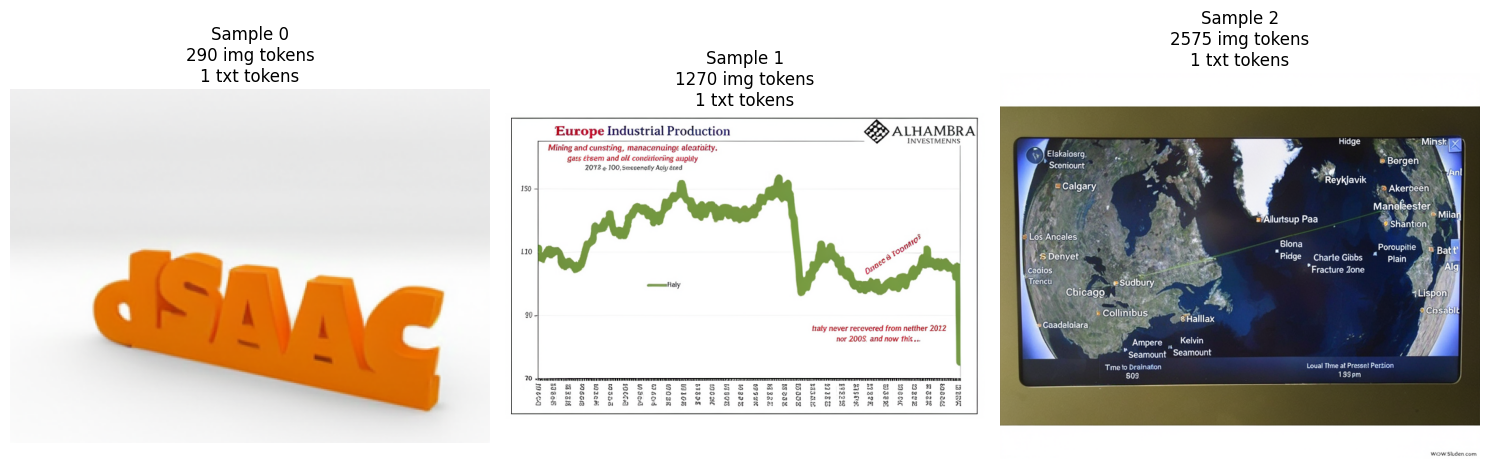


Sample 0 - Text Content (first 500 chars):
</s>

Sample 1 - Text Content (first 500 chars):
</s>

Sample 2 - Text Content (first 500 chars):
</s>


In [37]:
# Display all results in a grid
fig, axes = plt.subplots(1, n_samples, figsize=(15, 5))
if n_samples == 1:
    axes = [axes]

for i, (ax, result) in enumerate(zip(axes, results)):
    if result['image'] is not None:
        ax.imshow(result['image'])
        ax.set_title(f"Sample {i}\n{result['image_tokens']} img tokens\n{result['text_tokens']} txt tokens")
    else:
        ax.text(0.5, 0.5, f"No image\n{result['text_tokens']} text tokens", 
                ha='center', va='center')
        ax.set_title(f"Sample {i}")
    ax.axis('off')

plt.tight_layout()
plt.show()

# Display text snippets
for i, result in enumerate(results):
    print(f"\n{'='*60}")
    print(f"Sample {i} - Text Content (first 500 chars):")
    print(result['text'][:500])
    if len(result['text']) > 500:
        print("[... truncated ...]")

## 8. Analyze Token Distribution

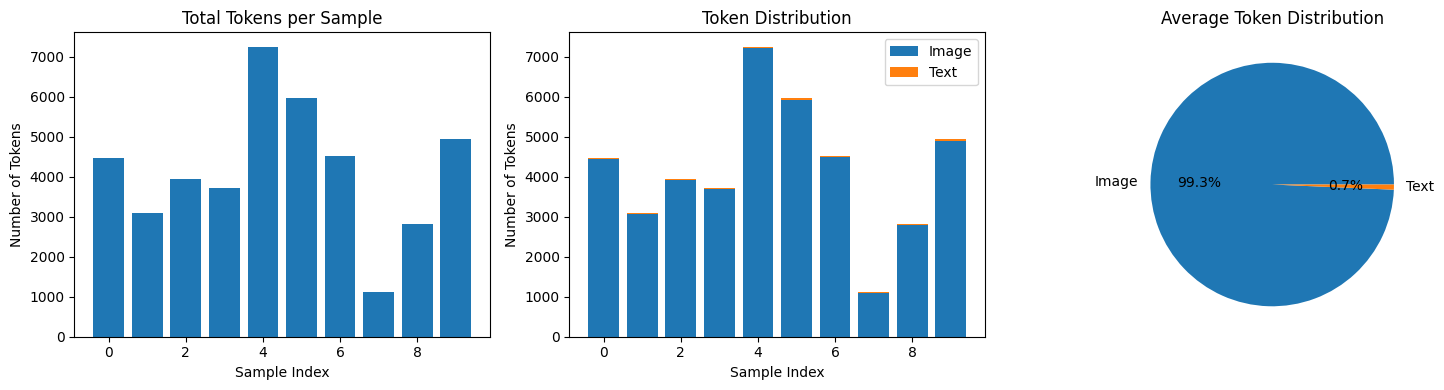


Statistics across 10 samples:
Average total tokens: 4179.4
Average image tokens: 4151.1 (99.3%)
Average text tokens: 28.3 (0.7%)


In [13]:
# Analyze token distribution across all samples
all_image_tokens = []
all_text_tokens = []
all_total_tokens = []

for i in range(min(10, len(dataset))):
    tokens = load_sample(dataset, i)
    image_tokens, text_tokens = split_image_text_tokens(tokens, sft_tokenizer.img_end_id)
    
    all_total_tokens.append(len(tokens))
    if image_tokens is not None:
        all_image_tokens.append(len(image_tokens))
        all_text_tokens.append(len(text_tokens))
    else:
        all_image_tokens.append(0)
        all_text_tokens.append(len(tokens))

# Plot distribution
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].bar(range(len(all_total_tokens)), all_total_tokens)
axes[0].set_title('Total Tokens per Sample')
axes[0].set_xlabel('Sample Index')
axes[0].set_ylabel('Number of Tokens')

axes[1].bar(range(len(all_image_tokens)), all_image_tokens, label='Image')
axes[1].bar(range(len(all_text_tokens)), all_text_tokens, bottom=all_image_tokens, label='Text')
axes[1].set_title('Token Distribution')
axes[1].set_xlabel('Sample Index')
axes[1].set_ylabel('Number of Tokens')
axes[1].legend()

# Pie chart for average distribution
avg_image = np.mean(all_image_tokens)
avg_text = np.mean(all_text_tokens)
axes[2].pie([avg_image, avg_text], labels=['Image', 'Text'], autopct='%1.1f%%')
axes[2].set_title('Average Token Distribution')

plt.tight_layout()
plt.show()

print(f"\nStatistics across {len(all_total_tokens)} samples:")
print(f"Average total tokens: {np.mean(all_total_tokens):.1f}")
print(f"Average image tokens: {np.mean(all_image_tokens):.1f} ({np.mean(all_image_tokens)/np.mean(all_total_tokens)*100:.1f}%)")
print(f"Average text tokens: {np.mean(all_text_tokens):.1f} ({np.mean(all_text_tokens)/np.mean(all_total_tokens)*100:.1f}%)")